In [2]:
#!pip install spacy
#!python -m spacy download en_core_web_trf

In [3]:
import pandas as pd
import spacy
from tqdm import tqdm
from pathlib import Path

Path("outputs").mkdir(exist_ok=True)

df = pd.read_parquet("data/news_with_topics_labeled.parquet")

nlp = spacy.load("en_core_web_trf")

In [4]:
records = []

for idx, row in tqdm(df.iterrows(), total=len(df)):
    text = row["article_text"][:3000]
    doc = nlp(text)
    
    for ent in doc.ents:
        if ent.label_ in ["ORG", "PRODUCT"]:
            records.append({
                "article_id": idx,
                "entity": ent.text.strip(),
                "entity_type": ent.label_,
                "topic": row["topic"],
                "topic_label": row["topic_label"]
            })

entities = pd.DataFrame(records)

entities.head()

100%|██████████| 30000/30000 [14:21:15<00:00,  1.72s/it]     


,article_id,entity,entity_type,topic,topic_label
0,0,Delaware First Media,ORG,-1,Other / Mixed Topic
1,0,Delaware First Media,ORG,-1,Other / Mixed Topic
2,0,Community Advisory Board,ORG,-1,Other / Mixed Topic
3,0,Board of Directors,ORG,-1,Other / Mixed Topic
4,0,Community Advisory Board,ORG,-1,Other / Mixed Topic


In [5]:
entities["entity_clean"] = (
    entities["entity"]
    .str.replace(r"[^A-Za-z0-9&.\- ]", "", regex=True)
    .str.strip()
)

entities = entities[entities["entity_clean"].str.len() >= 2]

In [6]:
top_entities = (
    entities["entity_clean"]
    .value_counts()
    .reset_index()
)

top_entities.columns = ["entity", "mentions"]

top_entities.head(30)

,entity,mentions
0,OpenAI,19734
1,ChatGPT,16979
2,Google,13210
3,Microsoft,11173
4,Apple,5669
5,Meta,4480
6,Nvidia,4252
7,Amazon,3415
8,Nasdaq,3329
9,Anthropic,2702


In [4]:
import pandas as pd

top_entities = pd.DataFrame({
    "entity": [
        "OpenAI","ChatGPT","Google","Microsoft","Apple","Meta",
        "Nvidia","Amazon","Nasdaq","Anthropic","Facebook",
        "LinkedIn","Samsung","NVIDIA","YouTube","Gemini",
        "NPR","NPR News","Mint","Reuters","iPhone","AMD",
        "Intel","Twitter","Bard","IBM","AP","DeepSeek",
        "Bing","AWS"
    ],
    "mentions": [
        19734,16979,13210,11173,5669,4480,
        4252,3415,3329,2702,2330,
        1860,1758,1749,1738,1736,
        1699,1592,1408,1371,1347,1285,
        1284,1250,1243,1243,1181,1179,
        1159,1103
    ]
})

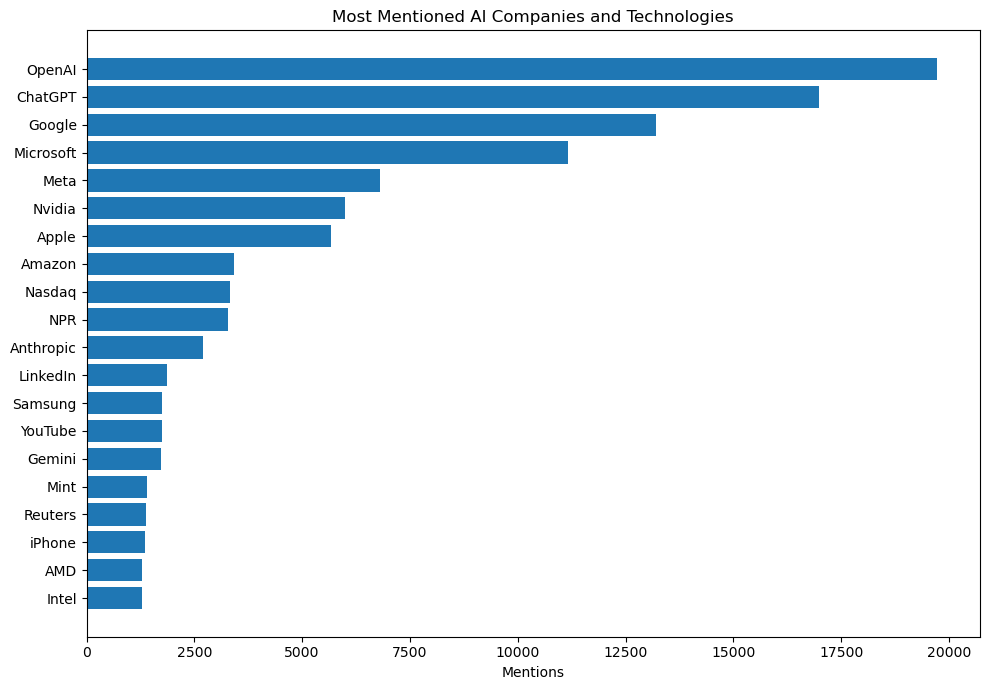

In [5]:
import matplotlib.pyplot as plt
from pathlib import Path

Path("figures").mkdir(exist_ok=True)

# optional normalization
top_entities["entity"] = top_entities["entity"].replace({
    "NVIDIA": "Nvidia",
    "NPR News": "NPR",
    "Facebook": "Meta",
    "Bard": "Google Bard"
})

top_entities = (
    top_entities
    .groupby("entity", as_index=False)["mentions"]
    .sum()
    .sort_values("mentions", ascending=False)
)

top20 = (
    top_entities
    .head(20)
    .sort_values("mentions")
)

plt.figure(figsize=(10,7))

plt.barh(
    top20["entity"],
    top20["mentions"]
)

plt.xlabel("Mentions")
plt.title("Most Mentioned AI Companies and Technologies")

plt.tight_layout()

plt.savefig(
    "figures/top_entities.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [6]:
top_entities.to_csv(
    "outputs/top_entities_cleaned.csv",
    index=False
)